In [2]:
# PS C:\Users\EmmaGolub/Desktop\MRoS_local> conda activate C:\Users\EmmaGolub\Desktop\MRoS_local\venv

"""
Data Assimilation Preprocessing

Workflow
1. Station data
    1a. load_station_meta(): 
        Reads the station metadata CSV and joins with per-station data files 
        to bring in elevation, latitude, longitude, and timezone for each station ID.
    1b. load_station_timeseries(): 
        Reads individual station CSVs, converts timestamps from local timezones to UTC,
        and standardizes the column structure across stations (temp_air, temp_dew, RH).
    1c. hourly_station_agg(): 
        Collapses all station data to the hourly level — at each hour, averages all 
        observations within that hour for each station. This produces one row per station-hour.
    1d. lapse_adjusted_idw_fill(): 
        After aggregation, fills missing hourly station temperature values using an 
        altitude-corrected 2D IDW approach that mirrors RainOrSnowTools::model_meteo():
            • Estimate a dynamic lapse rate (°C/m) from available stations at each hour 
              via regression of temperature vs elevation; fall back to a static lapse (-0.0065 K/m) if unstable.
            • Normalize station temperatures to a reference elevation 
              (typically the median of available station elevations).
            • Perform 2D IDW interpolation on the normalized values in a projected CRS.
            • De-normalize the interpolated values back to each station's elevation.
        This produces a physically consistent, vertically adjusted infill for missing temperatures.
    1e. fill_station_row_vars(): 
        Recomputes dependent meteorological variables for all hourly station records:
            • Dewpoint (Td) from temperature (Ta) and relative humidity (RH)
            • Relative humidity (RH) from Ta and Td when missing
            • Wet-bulb temperature (Tw) using Stull (2011), with a psychrometric fallback
        Ensures all hourly station predictors (Ta, Td, RH, Tw) are mutually consistent.

2. IMERG: 
    2a. Converts wide parquet files to long format, parses timestamps, 
        and averages the two 30-minute IMERG products within each hour to produce hourly mean PLP (%) values.
    2b. Appends DEM elevation to each IMERG grid coordinate for later use in modeling.

3. MRoS: 
    3a. Aggregates MRoS (crowdsourced precipitation-phase) observations to the hourly level.
        If multiple observations occur from the same observer within the hour, 
        retains only the latest record (assuming a correction to earlier input).
    3b. Converts categorical phase ("snow" / "mix" / "rain") to numeric proxy values 
        (0 = snow, 50 = mix, 100 = rain) and appends DEM elevation at each point.

4. Final harmonization: 
    By this stage, all datasets (stations, IMERG, MRoS) share consistent columns:
        • lat, lon, elev
        • datetime_utc (floored to hour)
        • predictor variables (e.g., temp_air, rh, plp, mros_plp_proxy)
    Each dataset is filtered spatially to the DEM AOI boundary before export.
"""


import re
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
import rasterio as rio
from rasterio.warp import transform_bounds, reproject, Resampling, calculate_default_transform
from pyproj import CRS, Transformer
import pytz
from sklearn.linear_model import LinearRegression
import math
from scipy.spatial import cKDTree


# ====================================================================
# REGION TOGGLE — change this to switch between CA and CO runs
# ====================================================================
REGION = "CA"   # "CA" = Sierra Nevada / Lake Tahoe
                 # "CO" = Colorado Mountains

REGION_CONFIG = {
    "CA": {
        "label":       "California: Sierra Nevada / Lake Tahoe",
        "utm_crs":     "EPSG:26911",   # UTM Zone 11N
        "dem_file":    "CA_DEM_AOI_1km.tif",
        "station_sub": "CA",
        "imerg_sub":   "CA",
        "aoi_lonlat": [
            (-119.45505750721992, 39.65343608043361),
            (-121.27878797084242, 39.66189413918429),
            (-119.11448133630248, 36.726935737063016),
            (-118.49924696303225, 37.235952484988736),
            (-119.46604383531404, 38.37304030164334),
        ],
    },
    "CO": {
        "label":       "Colorado Mountains",
        "utm_crs":     "EPSG:32613",   # UTM Zone 13N
        "dem_file":    "CO_DEM_AOI_1km.tif",
        "station_sub": "CO",
        "imerg_sub":   "CO",
        "aoi_lonlat": [
            (-105.19885928678391, 40.62046076499234),
            (-106.88927700287375, 40.555465783967925),
            (-107.66078646416787, 38.79540171139857),
            (-104.87856373593310, 38.77382201116306),
        ],
    },
}

rcfg = REGION_CONFIG[REGION]
print(f"Running region: {REGION} — {rcfg['label']}")


Running region: CA — California: Sierra Nevada / Lake Tahoe


# Path setups

In [4]:
# --------------------------- CONFIG ---------------------------------
BASE_DIR = Path().resolve().parent  # notebook lives at <repo>/Scripts/data_collection/
                                    # adjust to .parents[0] if directly in Scripts/
print("BASE_DIR:", BASE_DIR)

date_suffix = "20221001_20260501"   # matches download_station_data.R output filenames

CONFIG = {
    "wy_start":    "2022-10-01T00:00:00Z",
    "wy_end":      "2026-05-01T23:59:59Z",
    "test_start":  "2022-10-01T00:00:00Z",
    "test_end":    "2023-05-01T23:59:59Z",

    # Station data — region-specific subfolder
    "station_meta_csv": BASE_DIR / f"Data/Stations/{rcfg['station_sub']}/station_metadata_{date_suffix}.csv",
    "station_dir":      BASE_DIR / f"Data/Stations/{rcfg['station_sub']}",

    # IMERG — region-specific subfolder
    "imerg_dir":        BASE_DIR / f"Data/IMERG/{rcfg['imerg_sub']}",

    # MRoS observations — combined regions parquet
    "mros_parquet":     BASE_DIR / f"Data/observations/mros_ca_co_20221001_20260501.parquet",

    # DEM — output of preprocessing_DEM.ipynb
    "dem_path":         BASE_DIR / f"Data/Elevation/{rcfg['dem_file']}",

    # Outputs — region-specific subfolder
    "out_dir":          BASE_DIR / f"outputs/assimilated/{REGION}",
}

out_dir = Path(CONFIG["out_dir"])
out_dir.mkdir(parents=True, exist_ok=True)
(out_dir / "hourly_data").mkdir(parents=True, exist_ok=True)

CRS_WGS84 = "EPSG:4326"
CRS_DEM   = rcfg["utm_crs"]   # UTM 11N for CA, UTM 13N for CO
CRS_WEB   = "EPSG:3857"       # map display only

print(f"Station dir : {CONFIG['station_dir']}")
print(f"DEM path    : {CONFIG['dem_path']}")
print(f"Output dir  : {CONFIG['out_dir']}")
print(f"CRS_DEM     : {CRS_DEM}")


BASE_DIR: C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype
Station dir : C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\Data\Stations\CA
DEM path    : C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\Data\Elevation\CA_DEM_AOI_1km.tif
Output dir  : C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype\outputs\assimilated\CA
CRS_DEM     : EPSG:26911


# Utility Functions

In [12]:
# ------------------------- UTIL: time --------------------------------
def to_utc(dt_series: pd.Series) -> pd.DatetimeIndex:
    """Force timestamps to UTC, making naive → UTC-naive assumed in UTC."""
    dt = pd.to_datetime(dt_series, errors="coerce", utc=True)
    # If dt_series had naive datetimes and pandas assumed local, .tz_convert('UTC') not needed.
    return dt

def hourly_index(start_iso: str, end_iso: str) -> pd.DatetimeIndex:
    return pd.date_range(start=pd.to_datetime(start_iso), end=pd.to_datetime(end_iso),
                         freq="H", tz="UTC")

def print_time(ts):
    return pd.to_datetime(ts).strftime("%Y-%m-%d %H:%MZ")


def apply_physical_cutoffs(df: pd.DataFrame, verbose: bool = False) -> pd.DataFrame:
    """
    Null values outside hard physical bounds in-place.
    Safe to call on both raw sub-hourly rows and aggregated hourly data.
    """
    PHYSICAL_CUTOFFS = {
        "temp_air": (-45, 45),
        "temp_dew": (-50, 25),
        "rh":       (0, 100),
    }
    for col, (lo, hi) in PHYSICAL_CUTOFFS.items():
        if col not in df.columns:
            continue
        mask = (df[col] < lo) | (df[col] > hi)
        n = mask.sum()
        if n > 0:
            if verbose:
                print(f"  Physical cutoff: nulled {n} {col} values (bounds [{lo}, {hi}])")
            df.loc[mask, col] = np.nan
    return df

In [13]:
# ---------------------- UTIL: meteorology functions -------------------------

# Magnus (Tetens) saturation vapor pressure over water (°C)
#  How much moisture air can hold at saturation
def esat_hpa(Tc: float) -> float:
    return 6.112 * np.exp(17.27 * Tc / (Tc + 237.3))

# Dew point temperature from air temperature and relatuve humidity
#  Essentially rearranges Magnus equation.
def td_from_ta_rh(TaC: np.ndarray, RH: np.ndarray) -> np.ndarray:
    """Dewpoint from air temp (°C) and RH (%)"""
    TaC = np.asarray(TaC, dtype=float)
    RH = np.clip(np.asarray(RH, dtype=float), 1e-6, 100.0)
    a, b = 17.27, 237.3
    gamma = np.log(RH / 100.0) + (a * TaC) / (b + TaC)
    Td = (b * gamma) / (a - gamma)
    return Td

# Relative humidity from air temperature and dewpoint
#  (Inverse of dew point calculation)
def rh_from_ta_td(TaC: np.ndarray, TdC: np.ndarray) -> np.ndarray:
    """RH (%) from air temp and dewpoint (°C)"""
    TaC = np.asarray(TaC, dtype=float)
    TdC = np.asarray(TdC, dtype=float)
    a, b = 17.27, 237.3
    ln_es_Ta = (a * TaC) / (b + TaC)
    ln_es_Td = (a * TdC) / (b + TdC)
    RH = 100.0 * np.exp(ln_es_Td - ln_es_Ta)
    return np.clip(RH, 0.0, 100.0)

# Approximates wet-bulb temperature using Stull's (2011) empirical formula
#  Reflects evaporative cooling (snow vs rain)
def tw_stull(TaC: np.ndarray, RH: np.ndarray) -> np.ndarray:
    """
    Wet-bulb approximation (°C) by Stull (2011).
    TaC in °C, RH in %
    """
    TaC = np.asarray(TaC, dtype=float)
    RH = np.clip(np.asarray(RH, dtype=float), 1e-6, 100.0)
    Tw = (TaC * np.arctan(0.151977 * np.sqrt(RH + 8.313659)) +
          np.arctan(TaC + RH) - np.arctan(RH - 1.676331) +
          0.00391838 * RH**1.5 * np.arctan(0.023101 * RH) - 4.686035)
    return Tw


# --- Supplementary meteorology functions ---
def psychrometric_tw(TaC: float, RH: float, P_hPa: float = 1013.25) -> float:
    """
    Psychrometric wet bulb temperature (°C).
    Iterative solution of energy balance.
    TaC : air temp in °C
    RH  : relative humidity in %
    P_hPa : pressure in hPa (default sea level)
    """
    TaC = float(TaC)
    RH = float(RH)
    if not math.isfinite(TaC) or not math.isfinite(RH):
        return np.nan
    # Actual vapor pressure (hPa)
    ea = (RH / 100.0) * esat_hpa(TaC)
    # Psychrometric constant (hPa/°C)
    cp = 1004.0        # J/kg/K
    Lv = 2.5e6         # J/kg
    epsilon = 0.622    # ratio of molecular weights
    gamma = cp * P_hPa / (Lv * epsilon) / 100.0  # hPa/°C
    # Iterative solve
    Tw = TaC
    for _ in range(50):
        es_tw = esat_hpa(Tw)
        rhs = (TaC - Tw) * gamma
        lhs = es_tw - ea
        Tw_new = Tw + 0.2 * (rhs - lhs)  # relaxation step
        if abs(Tw_new - Tw) < 0.01:
            break
        Tw = Tw_new
    return Tw

def fill_station_row_vars(df: pd.DataFrame) -> pd.DataFrame:
    """
    Fill missing dewpoint, RH, and wet-bulb for each row.
    Uses Stull (2011) for wet-bulb, with fallback to iterative psychrometric solution
    when Stull produces physically inconsistent results.
    """
    # --- Dewpoint / RH consistency ---
    if "temp_air" in df.columns and "temp_dew" in df.columns and "rh" in df.columns:
        missing_rh = df["rh"].isna() & df["temp_air"].notna() & df["temp_dew"].notna()
        df.loc[missing_rh, "rh"] = rh_from_ta_td(
            df.loc[missing_rh, "temp_air"], df.loc[missing_rh, "temp_dew"]
        )
            # if "temp_air" in df and "temp_dew" in df and "rh" not in df:
            #     df["rh"] = rh_from_ta_td(df["temp_air"], df["temp_dew"])
    if "temp_air" in df.columns and "rh" in df.columns and "temp_dew" in df.columns:
        missing_td = df["temp_dew"].isna() & df["temp_air"].notna() & df["rh"].notna()
        df.loc[missing_td, "temp_dew"] = td_from_ta_rh(
            df.loc[missing_td, "temp_air"], df.loc[missing_td, "rh"]
        )
            # if "temp_air" in df and "rh" in df and "temp_dew" not in df:
            #     df["temp_dew"] = td_from_ta_rh(df["temp_air"], df["rh"])
    # Clamp RH values
    if "rh" in df:
        df["rh"] = np.clip(df["rh"].astype(float), 0, 100)
    # --- Wet-bulb temperature ---
    if "temp_air" in df and "rh" in df:
        Ta = df["temp_air"].astype(float)
        RH = df["rh"].astype(float)
        # First pass: Stull formula
        Tw_stull = tw_stull(Ta, RH)
        # Initialize with Stull values
        df["temp_wet"] = Tw_stull
        # Fallback check (rainOrSnowTools style):
        # - Wet bulb must lie between dewpoint and air temp
        if "temp_dew" in df:
            Td = df["temp_dew"].astype(float)
            bad_mask = (Tw_stull < Td) | (Tw_stull > Ta)
        else:
            bad_mask = (Tw_stull > Ta)
        if bad_mask.any():
            df.loc[bad_mask, "temp_wet"] = [
                psychrometric_tw(Ta_i, RH_i) for Ta_i, RH_i in zip(Ta[bad_mask], RH[bad_mask])
            ]
    return df


# --- Dynamic lapse rate each timestep ---
def estimate_lapse_rate(stations: pd.DataFrame, default=-0.005):
    """
    Estimate lapse rate °C/m from stations. Fallback to default if regression fails.
    """
    if len(stations) < 5 or stations["temp_air"].isna().all():
        return default
    X = stations[["elev"]].values
    y = stations["temp_air"].values
    if np.all(np.isfinite(X)) and np.all(np.isfinite(y)):
        model = LinearRegression().fit(X, y)
        slope = model.coef_[0]  # °C/m
        if -0.009 < slope < -0.003:  # reasonable range
            return slope
    return default

# --- DEM elevation append for consistency ---
import rasterio
def add_dem_elev(df, dem_path):
    with rio.open(CONFIG["dem_path"]) as src:
        transformer = Transformer.from_crs(CRS_WGS84, CRS_DEM, always_xy=True)
        xs, ys = transformer.transform(df["lon"].values, df["lat"].values)
        df["elev"] = np.array([v[0] for v in src.sample(zip(xs, ys))])
    return df



In [14]:
# Function for appending elevation from this DEM to a dataset (i.e., for IMERG, MRoS...)

## Old:
# def add_elev_from_src(df, src, lon_col="lon", lat_col="lat"):
#     coords = list(zip(df[lon_col], df[lat_col]))
#     elev = np.array([val[0] for val in src.sample(coords)])
#     return df.assign(elev=elev)

def add_elev_from_src(df, src, lon_col="lon", lat_col="lat"):
    transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
    xs, ys = transformer.transform(df[lon_col].values, df[lat_col].values)
    elev = np.array([val[0] for val in src.sample(zip(xs, ys))])
    # nodata → NaN
    nodata = src.nodata
    if nodata is not None:
        elev = np.where(elev == nodata, np.nan, elev)
    return df.assign(elev=elev)

# Load and process all datasets

## Stations

In [15]:
# -------------------- LOAD: Stations ---------------------------------

def load_station_meta(meta_csv: str) -> pd.DataFrame:
    meta = pd.read_csv(meta_csv)
    req = {"id", "lat", "lon", "elev", "timezone_lst"}
    missing = req - set(meta.columns)
    if missing:
        raise ValueError(f"Station metadata missing columns: {missing}")
    meta["id"] = meta["id"].astype(str)
    return meta


def load_station_timeseries(station_dir: str, meta: pd.DataFrame) -> pd.DataFrame:
    files = [p for p in Path(station_dir).glob("*.csv") if "meta" not in p.name.lower()]
    dfs = []
    tz_failed_stations = []

    for f in files:
        df = pd.read_csv(f, low_memory=False)
        if "id" not in df.columns:
            df["id"] = f.stem
        keep = ["id", "datetime", "temp_air", "temp_dew", "rh"]
        for k in keep:
            if k not in df.columns:
                df[k] = np.nan
        df = df[keep]
        df["id"] = df["id"].astype(str)

        # Drop repeated header rows (artifact of appended downloads)
        df = df[df["datetime"] != "datetime"]

        # Coerce met columns to numeric — bad/string values become NaN
        for col in ["temp_air", "temp_dew", "rh"]:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        # --- Hard physical cutoffs ---
        df = apply_physical_cutoffs(df)

        tz_vals = meta.loc[meta["id"] == df["id"].iloc[0], "timezone_lst"].values
        dt_local = pd.to_datetime(df["datetime"], errors="coerce")
        if len(tz_vals) == 1:
            try:
                tz = pytz.timezone(tz_vals[0])
                if getattr(dt_local.dt, "tz", None) is None:
                    df["datetime"] = dt_local.dt.tz_localize(tz, ambiguous="NaT", nonexistent="NaT").dt.tz_convert("UTC")
                else:
                    df["datetime"] = dt_local.dt.tz_convert("UTC")
            except Exception as e:
                tz_failed_stations.append(df["id"].iloc[0])
                print(f"Warning: timezone '{tz_vals}' failed for station {df['id'].iloc[0]}: {e}")
                df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce", utc=True)
        else:
            df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce", utc=True)
        dfs.append(df)

    if tz_failed_stations:
        print(f"\n*** {len(tz_failed_stations)} station(s) fell back to UTC-naive: {tz_failed_stations}")
        print("    Check these manually — timestamps may be off by hours.\n")

    if not dfs:
        return pd.DataFrame(columns=["id", "datetime", "temp_air", "temp_dew", "rh"])
    return pd.concat(dfs, ignore_index=True)


def hourly_station_agg(st_df: pd.DataFrame, meta: pd.DataFrame) -> pd.DataFrame:
    """
    Collapse station data to the hourly level per station.
    Applies hard physical cutoffs, within-station spike detection,
    stuck-sensor detection, and cross-variable consistency checks.
    """
    df = st_df.merge(meta, on="id", how="left")
    df["hour_utc"] = df["datetime"].dt.floor("h")

    agg = (df.groupby(["id", "hour_utc"], as_index=False)
             .agg(temp_air=("temp_air", "mean"),
                  temp_dew=("temp_dew", "mean"),
                  rh=("rh", "mean"),
                  lat=("lat", "first"),
                  lon=("lon", "first"),
                  elev=("elev", "first")))

    # # --- Hard physical cutoffs ---
    agg = apply_physical_cutoffs(agg, verbose=True)
    # cutoffs = {"temp_air": (-45, 45), "temp_dew": (-50, 25)}
    # for col, (lo, hi) in cutoffs.items():
    #     agg.loc[(agg[col] < lo) | (agg[col] > hi), col] = np.nan

    # --- Per-station IQR outlier filter ---
    IQR_MULTIPLIER = 3.0  # conservative; use 2.5 to be stricter
    for col in ["temp_air", "temp_dew"]:
        if col not in agg.columns:
            continue
        q1 = agg.groupby("id")[col].transform("quantile", 0.25)
        q3 = agg.groupby("id")[col].transform("quantile", 0.75)
        iqr = q3 - q1
        lo  = q1 - IQR_MULTIPLIER * iqr
        hi  = q3 + IQR_MULTIPLIER * iqr
        mask = (agg[col] < lo) | (agg[col] > hi)
        n_flagged = mask.sum()
        if n_flagged > 0:
            print(f"  IQR filter: nulled {n_flagged} {col} values (>{IQR_MULTIPLIER}xIQR per station)")
        agg.loc[mask, col] = np.nan
    
    # --- Within-station spike detection ---
    SPIKE_THRESHOLDS = {"temp_air": 10.0, "temp_dew": 8.0, "rh": 40.0}
    agg = agg.sort_values(["id", "hour_utc"]).reset_index(drop=True)
    for col, thresh in SPIKE_THRESHOLDS.items():
        if col not in agg.columns:
            continue
        delta = agg.groupby("id")[col].diff().abs()
        n_spiked = (delta > thresh).sum()
        if n_spiked > 0:
            print(f"  Spike filter: nulled {n_spiked} {col} values (>{thresh}/hr step)")
        agg.loc[delta > thresh, col] = np.nan

    # --- Stuck-sensor detection ---
    # Null runs of >= 6 consecutive identical values in temp_air and temp_dew.
    MIN_RUN_LENGTH = 6
    for col in ["temp_air", "temp_dew"]:
        if col not in agg.columns:
            continue
        is_same = agg.groupby("id")[col].transform(lambda s: s == s.shift(1))
        # Use a temporary column to avoid passing anonymous Series to groupby
        agg["_run_id"] = (~is_same).groupby(agg["id"]).cumsum()
        run_len = is_same.groupby([agg["id"], agg["_run_id"]]).transform("sum") + 1
        agg = agg.drop(columns=["_run_id"])
        stuck = (run_len >= MIN_RUN_LENGTH) & is_same
        n_stuck = stuck.sum()
        if n_stuck > 0:
            print(f"  Stuck-sensor filter: nulled {n_stuck} {col} values (run >= {MIN_RUN_LENGTH} hrs)")
        agg.loc[stuck, col] = np.nan

    # --- Cross-variable consistency ---
    if "temp_air" in agg.columns and "temp_dew" in agg.columns:
        agg.loc[agg["temp_dew"] > agg["temp_air"], "temp_dew"] = np.nan

    return agg


def lapse_adjusted_idw_multi(
    st_hr: pd.DataFrame,
    value_cols: list = ["temp_dew", "rh"],
    elev_col: str = "elev",
    lat_col: str = "lat",
    lon_col: str = "lon",
    time_col: str = "hour_utc",
    k: int = 6,
    power: float = 2.0,
    fallback_lapse: float = -0.0065,
    proj_in: str = CRS_WGS84,
    proj_out: str = CRS_DEM,
):
    """
    Lapse-rate-adjusted 2D IDW interpolation for multiple met variables.

    Performance improvements vs original:
      - Station coordinates projected once before the time loop (was per-hour).
      - workers=-1 replaces the deprecated n_jobs try/except.
      - Modeled values accumulated in pre-allocated NumPy arrays and written
        back to the DataFrame in a single assignment after the loop.
    """
    df = st_hr.copy().sort_values(["id", time_col]).reset_index(drop=True)
    thermal_vars = {"temp_air", "temp_dew", "temp_wet"}

    # Pre-project ALL station coordinates once (was repeated every hour)
    transformer = Transformer.from_crs(proj_in, proj_out, always_xy=True)
    all_px, all_py = transformer.transform(df[lon_col].values, df[lat_col].values)
    df["_px"] = all_px
    df["_py"] = all_py

    # Pre-allocate output arrays — avoids per-row .loc scatter writes
    modeled = {v: np.full(len(df), np.nan) for v in value_cols}

    bad_coords = df[~(np.isfinite(df["_px"]) & np.isfinite(df["_py"]))]["id"].unique()
    if len(bad_coords) > 0:
        print(f"  Warning: {len(bad_coords)} station(s) have invalid projected coordinates "
            f"and will be skipped in IDW: {bad_coords}")
    
    for t, group in df.groupby(time_col):
        lapse_source = group[group["temp_air"].notna() & group[elev_col].notna()]
        lapse = (estimate_lapse_rate(lapse_source, default=fallback_lapse)
                if len(lapse_source) >= 5 else fallback_lapse)

        z_ref = np.nanmean(group[elev_col].values)
        elev_vals = group[elev_col].values

        # Only query points with valid projected coordinates
        valid_mask = np.isfinite(group["_px"].values) & np.isfinite(group["_py"].values)
        if not valid_mask.any():
            continue

        gx = group["_px"].values[valid_mask]
        gy = group["_py"].values[valid_mask]
        elev_vals_valid = elev_vals[valid_mask]
        valid_idx = group.index[valid_mask]

        for v in value_cols:
            avail = group[group[v].notna() & group[elev_col].notna()
                        & group["_px"].notna() & group["_py"].notna()]
            if len(avail) < 4:
                continue

            tree     = cKDTree(np.c_[avail["_px"].values, avail["_py"].values])
            k_actual = min(k, len(avail))
            dists, idxs = tree.query(np.c_[gx, gy], k=k_actual, workers=-1)

            if k_actual == 1:
                dists = dists[:, np.newaxis]
                idxs  = idxs[:, np.newaxis]

            w  = 1.0 / np.maximum(dists, 1e-6) ** power
            w /= w.sum(axis=1, keepdims=True)

            if v in thermal_vars:
                vals_norm = avail[v].values - lapse * (avail[elev_col].values - z_ref)
                pred = np.sum(vals_norm[idxs] * w, axis=1) + lapse * (elev_vals_valid - z_ref)
            else:
                pred = np.sum(avail[v].values[idxs] * w, axis=1)

            modeled[v][valid_idx] = pred

    # Single bulk assignment back to DataFrame
    for v in value_cols:
        df[v + "_modeled"] = modeled[v]
        print(f"Lapse-adjusted modeled hourly station {v}: {np.sum(~np.isnan(modeled[v]))}")

    return df.drop(columns=["_px", "_py"])


# =============================================================================
# Run station pipeline
# =============================================================================

meta  = load_station_meta(CONFIG["station_meta_csv"])
st_ts = load_station_timeseries(CONFIG["station_dir"], meta)
st_hr = hourly_station_agg(st_ts, meta)

st_hr = st_hr[
    (st_hr["hour_utc"] >= pd.to_datetime(CONFIG["wy_start"])) &
    (st_hr["hour_utc"] <= pd.to_datetime(CONFIG["wy_end"]))
]
print(f"Stations hourly rows in window: {len(st_hr)}")

st_hr = lapse_adjusted_idw_multi(st_hr, value_cols=["temp_dew", "rh"])

for v in ["temp_dew", "rh"]:
    modeled_col = v + "_modeled"
    if modeled_col in st_hr.columns:
        st_hr[v] = st_hr[v].where(st_hr[v].notna(), st_hr[modeled_col])

st_hr = fill_station_row_vars(st_hr)

st_hr = st_hr.drop(columns=[c for c in st_hr.columns if c.endswith("_modeled")], errors="ignore")

print("Remaining missing values after fill:")
print(st_hr[["temp_dew", "rh", "temp_wet"]].isna().mean().round(3))

  IQR filter: nulled 290 temp_air values (>3.0xIQR per station)
  IQR filter: nulled 236 temp_dew values (>3.0xIQR per station)
  Spike filter: nulled 5172 temp_air values (>10.0/hr step)
  Spike filter: nulled 6061 temp_dew values (>8.0/hr step)
  Spike filter: nulled 812 rh values (>40.0/hr step)
  Stuck-sensor filter: nulled 32355 temp_air values (run >= 6 hrs)
  Stuck-sensor filter: nulled 67563 temp_dew values (run >= 6 hrs)
Stations hourly rows in window: 2605749
Lapse-adjusted modeled hourly station temp_dew: 2605749
Lapse-adjusted modeled hourly station rh: 2605749
Remaining missing values after fill:
temp_dew    0.000
rh          0.000
temp_wet    0.258
dtype: float64


In [17]:
# =============================================================================
# VISUALIZE: Station data checks — summary
# =============================================================================

# Station-level summary (one row per station, computed from post-AOI-clip st_hr)
st_meta_check = (
    st_hr.groupby("id", as_index=False)
    .agg(
        lat=("lat", "first"),
        lon=("lon", "first"),
        elev=("elev", "first"),
        n_hours=("hour_utc", "count"),
        ta_mean=("temp_air", "mean"),
        tw_mean=("temp_wet", "mean"),
        rh_mean=("rh", "mean"),
        ta_miss_frac=("temp_air", lambda x: x.isna().mean()),
    )
)

print(f"Unique stations in AOI: {len(st_meta_check)}")
print(f"Total hourly station-rows: {len(st_hr):,}")
print(f"\nElevation range: {st_meta_check['elev'].min():.0f}–{st_meta_check['elev'].max():.0f} m")
print(f"\nCompleteness (pre-fill gaps only affect temp_wet):")
print(f"  temp_air : {(1 - st_hr['temp_air'].isna().mean())*100:.1f}%")
print(f"  temp_wet : {(1 - st_hr['temp_wet'].isna().mean())*100:.1f}%")
print(f"  rh       : {(1 - st_hr['rh'].isna().mean())*100:.1f}%")
print(f"\nHours per station:")
print(st_meta_check["n_hours"].describe().round(0).to_string())

Unique stations in AOI: 493
Total hourly station-rows: 2,605,749

Elevation range: -5–3613 m

Completeness (pre-fill gaps only affect temp_wet):
  temp_air : 74.2%
  temp_wet : 74.2%
  rh       : 100.0%

Hours per station:
count      493.0
mean      5285.0
std       9695.0
min         14.0
25%        766.0
50%        768.0
75%        768.0
max      30000.0


c:\Users\EmmaGolub\Desktop\MRoS_local\venv\Lib\site-packages\geopandas\plotting.py:480: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  ax.figure.canvas.draw_idle()
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_32488\2930911142.py:147: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels([f"{lon:.2f}°" for lon in xlon], fontsize=7)
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_32488\2930911142.py:148: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels([f"{lat:.2f}°" for lat in ylat], fontsize=7)
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_32488\2930911142.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_32488

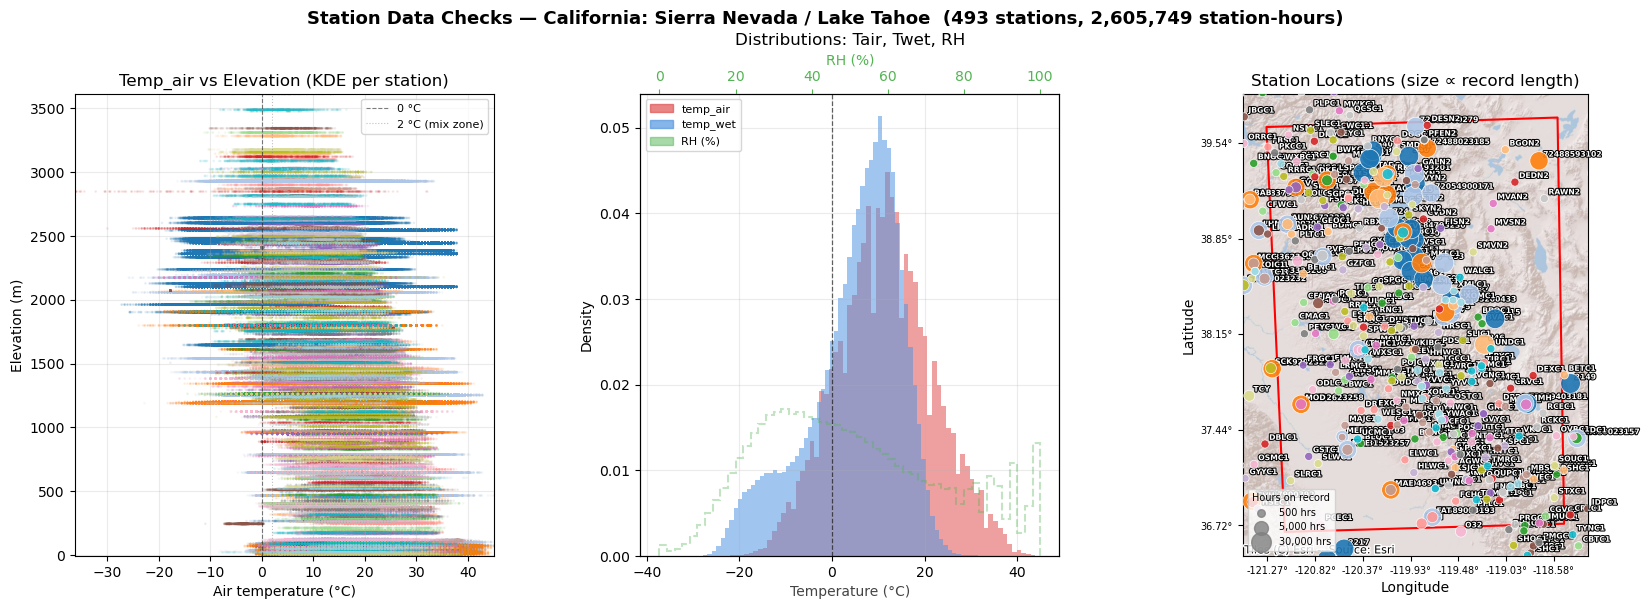

In [18]:
# =============================================================================
# VISUALIZE: Station data checks — 3-panel figure
# Panel 1: Temp_air vs elevation KDE (one dot per hourly obs, colored by station)
# Panel 2: Distributions of temp_air, temp_wet, rh
# Panel 3: Station locations on basemap with DEM footprint
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
import contextily as cx
import geopandas as gpd
import rasterio
from pyproj import Transformer

fig = plt.figure(figsize=(20, 6))
fig.suptitle(
    f"Station Data Checks — {rcfg['label']}  "
    f"({len(st_meta_check)} stations, {len(st_hr):,} station-hours)",
    fontsize=13, fontweight="bold", y=1.02,
)
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Color map: one color per station ─────────────────────────────────────────
station_ids  = st_meta_check["id"].tolist()
cmap_st      = plt.get_cmap("tab20", len(station_ids))
id_to_color  = {sid: cmap_st(i) for i, sid in enumerate(station_ids)}

# ── Panel 1: Temp_air vs elevation KDE per station ───────────────────────────
ax1 = fig.add_subplot(gs[0])

# One KDE contour per station that has enough obs
for sid in station_ids:
    sub = st_hr[st_hr["id"] == sid][["temp_air", "elev"]].dropna()
    if len(sub) < 20:
        continue
    try:
        kde = gaussian_kde(np.vstack([sub["temp_air"], sub["elev"]]))
        ta_grid = np.linspace(sub["temp_air"].min(), sub["temp_air"].max(), 60)
        el_grid = np.linspace(sub["elev"].min(),     sub["elev"].max(),     60)
        TA, EL  = np.meshgrid(ta_grid, el_grid)
        Z       = kde(np.vstack([TA.ravel(), EL.ravel()])).reshape(TA.shape)
        ax1.contour(TA, EL, Z, levels=3, colors=[id_to_color[sid]], alpha=0.55, linewidths=0.8)
    except Exception:
        pass

# Scatter: thin layer of all points
ax1.scatter(
    st_hr["temp_air"], st_hr["elev"],
    c=[id_to_color.get(sid, "gray") for sid in st_hr["id"]],
    s=1, alpha=0.08, rasterized=True,
)

ax1.axvline(0, color="black", lw=0.8, ls="--", alpha=0.5, label="0 °C")
ax1.axvline(2, color="gray",  lw=0.8, ls=":",  alpha=0.5, label="2 °C (mix zone)")
ax1.set_xlabel("Air temperature (°C)")
ax1.set_ylabel("Elevation (m)")
ax1.set_title("Temp_air vs Elevation (KDE per station)")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.25)

# ── Panel 2: Distributions of temp_air, temp_wet, rh ─────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2_rh = ax2.twiny()   # RH on top x-axis

colors_vars = {"temp_air": "#e05252", "temp_wet": "#5296e0", "rh": "#52b452"}

# Temp_air and temp_wet — bottom x-axis
for col, color in [("temp_air", colors_vars["temp_air"]),
                    ("temp_wet", colors_vars["temp_wet"])]:
    vals = st_hr[col].dropna()
    ax2.hist(vals, bins=80, color=color, alpha=0.55, density=True, label=col.replace("_", " "))

ax2.axvline(0, color="black", lw=0.9, ls="--", alpha=0.6)
ax2.set_xlabel("Temperature (°C)", color="#444")
ax2.set_ylabel("Density")
ax2.set_title("Distributions: Tair, Twet, RH")

# RH — top x-axis, dashed
rh_vals = st_hr["rh"].dropna()
ax2_rh.hist(rh_vals, bins=50, color=colors_vars["rh"], alpha=0.35,
            density=True, label="RH (%)", linestyle="dashed", histtype="step", linewidth=1.5)
ax2_rh.set_xlabel("RH (%)", color=colors_vars["rh"])
ax2_rh.tick_params(axis="x", colors=colors_vars["rh"])

# Combined legend
handles = [
    mpatches.Patch(color=colors_vars["temp_air"], alpha=0.7, label="temp_air"),
    mpatches.Patch(color=colors_vars["temp_wet"], alpha=0.7, label="temp_wet"),
    mpatches.Patch(color=colors_vars["rh"],       alpha=0.5, label="RH (%)"),
]
ax2.legend(handles=handles, fontsize=8, loc="upper left")
ax2.grid(alpha=0.25)

# ── Panel 3: Station locations on basemap ────────────────────────────────────
ax3 = fig.add_subplot(gs[2])

with rasterio.open(CONFIG["dem_path"]) as src:
    dem_bounds = src.bounds
    dem_crs    = src.crs

# DEM footprint in Web Mercator
from shapely.geometry import box as sbox
dem_poly  = sbox(*dem_bounds)
dem_gdf   = gpd.GeoDataFrame({"geometry": [dem_poly]}, crs=dem_crs).to_crs("EPSG:3857")

# Stations in Web Mercator
st_gdf = gpd.GeoDataFrame(
    st_meta_check,
    geometry=gpd.points_from_xy(st_meta_check["lon"], st_meta_check["lat"]),
    crs="EPSG:4326",
).to_crs("EPSG:3857")

# Assign colors and size by n_hours
st_gdf["color"] = [id_to_color[sid] for sid in st_gdf["id"]]
sz = np.interp(st_meta_check["n_hours"], 
               [st_meta_check["n_hours"].min(), st_meta_check["n_hours"].max()],
               [30, 200])

xmin, ymin, xmax, ymax = dem_gdf.total_bounds
buf = (xmax - xmin) * 0.08
ax3.set_xlim(xmin - buf, xmax + buf)
ax3.set_ylim(ymin - buf, ymax + buf)

cx.add_basemap(ax3, source=cx.providers.Esri.WorldShadedRelief, zoom=9, alpha=0.85)
dem_gdf.plot(ax=ax3, facecolor="none", edgecolor="red", linewidth=1.5, zorder=3)
ax3.scatter(st_gdf.geometry.x, st_gdf.geometry.y,
            c=st_gdf["color"], s=sz, edgecolors="white", linewidths=0.5, zorder=4, alpha=0.9)

# Annotate station IDs
for _, row in st_gdf.iterrows():
    ax3.annotate(row["id"], xy=(row.geometry.x, row.geometry.y),
                 xytext=(3, 3), textcoords="offset points", fontsize=5.5,
                 color="white", fontweight="bold",
                 path_effects=[
                     plt.matplotlib.patheffects.withStroke(linewidth=1.5, foreground="black")
                 ])

# Lat/lon tick labels
to_latlon = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)
xticks = ax3.get_xticks()
yticks = ax3.get_yticks()
xlon, _ = to_latlon.transform(xticks, [0] * len(xticks))
_, ylat  = to_latlon.transform([0] * len(yticks), yticks)
ax3.set_xticklabels([f"{lon:.2f}°" for lon in xlon], fontsize=7)
ax3.set_yticklabels([f"{lat:.2f}°" for lat in ylat], fontsize=7)
ax3.set_xlabel("Longitude"); ax3.set_ylabel("Latitude")

# Size legend (n_hours)
for n_label, s_val in [(500, 30), (5000, 100), (st_meta_check["n_hours"].max(), 200)]:
    ax3.scatter([], [], c="gray", s=s_val, label=f"{int(n_label):,} hrs", alpha=0.8)
ax3.legend(title="Hours on record", fontsize=7, title_fontsize=7, loc="lower left")
ax3.set_title("Station Locations (size ∝ record length)")

plt.tight_layout()
plt.savefig(out_dir / f"station_data_checks_{REGION}.png", dpi=150, bbox_inches="tight")
plt.show()

## IMERG

In [24]:
import pyarrow.parquet as pq
from pathlib import Path

imerg_dir = Path(f"C:/Users/mmaGolub/Desktop/MRoS_local/mros-precipitation-phase-product-prototype/Data/IMERG/{REGION}")

incomplete = []
for f in sorted(imerg_dir.glob("*.parquet")):
    schema = pq.read_schema(f)
    plp_cols = [c for c in schema.names if c.startswith("plp_")]
    if len(plp_cols) != 48:
        incomplete.append((f.name, len(plp_cols)))

print(f"{len(incomplete)} files with != 48 slots:")
for name, n in incomplete:
    print(f"  {name}: {n} slots")

0 files with != 48 slots:


In [27]:
# -------------------- LOAD: IMERG (wide→long→hourly) -----------------

# Dates like "2024-10-11 01:30:00" (space or "T" also OK)
TIME_COL_RE = re.compile(r"^\d{4}-\d{2}-\d{2}[ T]\d{2}:\d{2}(?::\d{2})?$")
DATE_ONLY_RE = re.compile(r"^\d{4}-\d{2}-\d{2}$")

PLO_SLOT_RE = re.compile(r"^plp_(\d{2})$")

def read_imerg_wide_to_long(path: Path) -> pd.DataFrame:
    import pyarrow.parquet as pq
    table = pq.read_table(path)
    df = table.to_pandas()
    df = df.rename(columns={"x": "lon", "y": "lat"})

    # --- Path 1: columns are already timestamps (legacy format) ---
    time_cols = [c for c in df.columns if TIME_COL_RE.match(str(c))]
    if not time_cols:
        any_timeish = [c for c in df.columns if re.match(r"^\d{4}-\d{2}-\d{2}", str(c))]
        time_cols = [c for c in any_timeish if not DATE_ONLY_RE.match(str(c))]

    if time_cols:
        long = df.melt(
            id_vars=["lat", "lon"],
            value_vars=time_cols,
            var_name="time_str",
            value_name="plp_raw",
        )
        long["time_utc"] = pd.to_datetime(long["time_str"], utc=True, errors="coerce")

    # --- Path 2: columns are plp_01..plp_48 — reconstruct from filename date ---
    else:
        slot_cols = sorted(
            [c for c in df.columns if PLO_SLOT_RE.match(str(c))],
            key=lambda c: int(PLO_SLOT_RE.match(c).group(1))
        )
        if not slot_cols:
            raise ValueError(f"No time-like or plp_NN columns found in {path.name}")

        date_match = re.search(r"(\d{4}-\d{2}-\d{2})", path.stem)
        if not date_match:
            raise ValueError(f"Cannot extract date from filename: {path.name}")
        file_date = pd.Timestamp(date_match.group(1), tz="UTC")

        long = df.melt(
            id_vars=["lat", "lon"],
            value_vars=slot_cols,
            var_name="slot",
            value_name="plp_raw",
        )
        slot_num = long["slot"].str.extract(r"plp_(\d+)")[0].astype(int)
        long["time_utc"] = file_date + pd.to_timedelta((slot_num - 1) * 30, unit="m")

    # --- Shared: scale and return ---
    plp = pd.to_numeric(long["plp_raw"], errors="coerce").astype(float)
    if np.nanmax(plp) <= 1.0:
        plp *= 100.0
    long["plp"] = plp

    return long.loc[long["time_utc"].notna(), ["time_utc", "lat", "lon", "plp"]]

def hourly_imerg(imerg_dir: str, start_iso: str, end_iso: str) -> pd.DataFrame:
    files = list(Path(imerg_dir).rglob("*.parquet"))
    if not files:
        print(f"[IMERG] No parquet files under {imerg_dir}")
        return pd.DataFrame(columns=["hour_utc", "lat", "lon", "plp"])

    start_ts = pd.to_datetime(start_iso, utc=True)
    end_ts   = pd.to_datetime(end_iso,   utc=True)

    dfs = []
    for f in files:
        df = read_imerg_wide_to_long(f)
        df = df[(df["time_utc"] >= start_ts) & (df["time_utc"] <= end_ts)]
        if not df.empty:
            dfs.append(df)

    if not dfs:
        print("[IMERG] Found files but no rows within the requested window.")
        return pd.DataFrame(columns=["hour_utc", "lat", "lon", "plp"])

    imerg = pd.concat(dfs, ignore_index=True)

    # Average the two half-hour slots within each hour per pixel
    imerg["hour_utc"] = imerg["time_utc"].dt.floor("h")
    imerg_hr = (imerg.groupby(["hour_utc", "lat", "lon"], as_index=False)
                      .agg(plp=("plp", "mean")))
    return imerg_hr

# run
imerg_hr = hourly_imerg(CONFIG["imerg_dir"], CONFIG["wy_start"], CONFIG["wy_end"])

# Append elevation
with rio.open(CONFIG["dem_path"]) as src:
    imerg_hr = add_elev_from_src(imerg_hr, src)

print(f"IMERG hourly points in window: {len(imerg_hr)}")

IMERG hourly points in window: 19710720


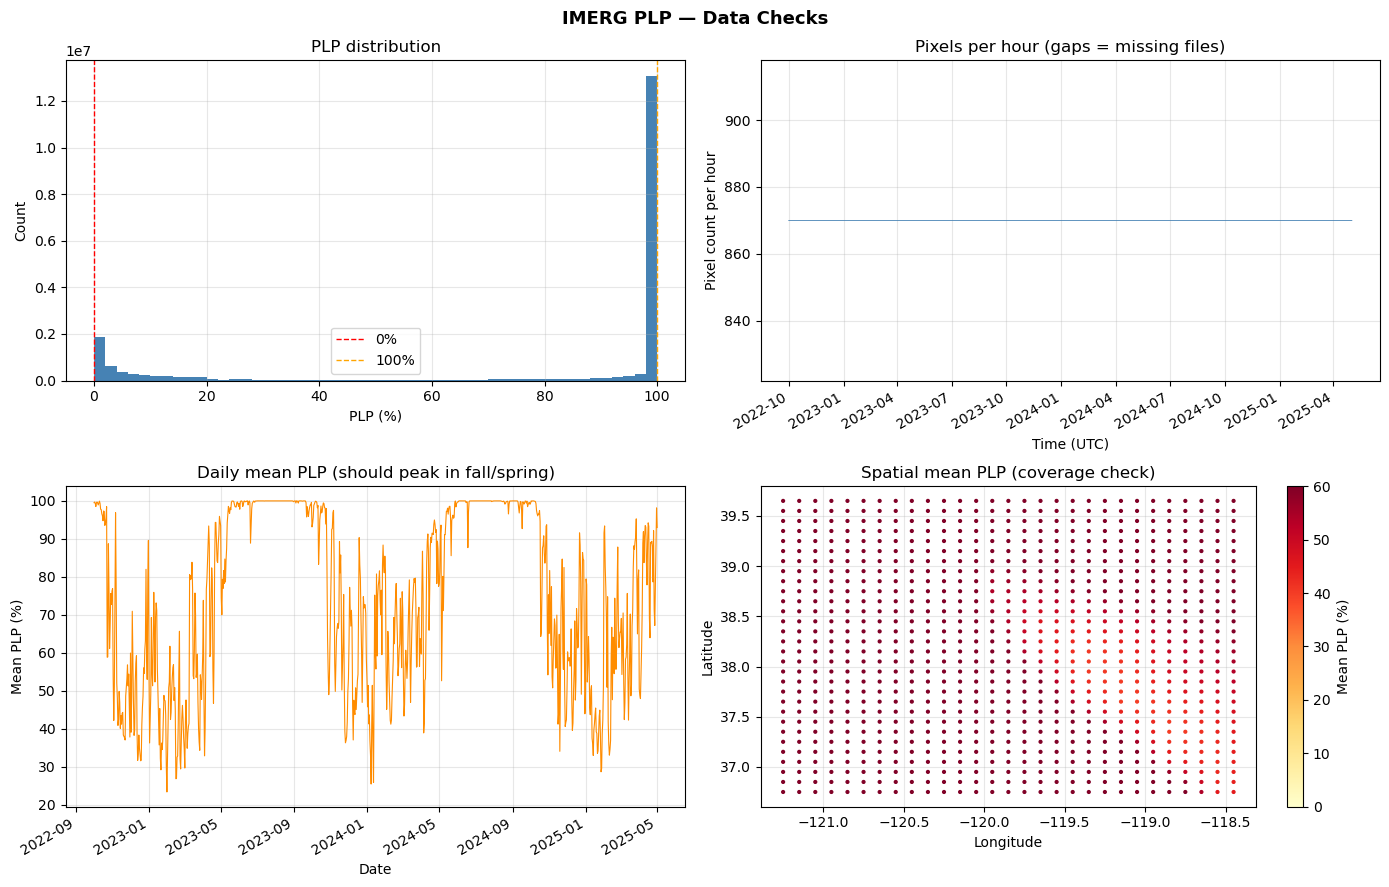

In [28]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("IMERG PLP — Data Checks", fontsize=13, fontweight="bold")

# --- 1. PLP distribution ---
ax = axes[0, 0]
ax.hist(imerg_hr["plp"].dropna(), bins=50, color="steelblue", edgecolor="none")
ax.axvline(0,   color="red",    linestyle="--", linewidth=1, label="0%")
ax.axvline(100, color="orange", linestyle="--", linewidth=1, label="100%")
ax.set_xlabel("PLP (%)")
ax.set_ylabel("Count")
ax.set_title("PLP distribution")
ax.legend()
ax.grid(alpha=0.3)

# --- 2. Hourly pixel count over time (completeness check) ---
ax = axes[0, 1]
counts = imerg_hr.groupby("hour_utc")["plp"].count()
ax.plot(counts.index, counts.values, linewidth=0.6, color="steelblue")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Pixel count per hour")
ax.set_title("Pixels per hour (gaps = missing files)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.grid(alpha=0.3)

# --- 3. Mean daily PLP over time (seasonal signal check) ---
ax = axes[1, 0]
imerg_hr["date"] = imerg_hr["hour_utc"].dt.date
daily_mean = imerg_hr.groupby("date")["plp"].mean()
ax.plot(daily_mean.index, daily_mean.values, linewidth=0.8, color="darkorange")
ax.set_xlabel("Date")
ax.set_ylabel("Mean PLP (%)")
ax.set_title("Daily mean PLP (should peak in fall/spring)")
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.grid(alpha=0.3)

# --- 4. Spatial coverage — mean PLP per pixel ---
ax = axes[1, 1]
spatial = imerg_hr.groupby(["lat", "lon"])["plp"].mean().reset_index()
sc = ax.scatter(spatial["lon"], spatial["lat"], c=spatial["plp"],
                cmap="YlOrRd", s=4, vmin=0, vmax=60)
plt.colorbar(sc, ax=ax, label="Mean PLP (%)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Spatial mean PLP (coverage check)")
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

In [26]:
# Load raw parquet for checks
import pyarrow.parquet as pq
_pf = pq.read_table(CONFIG["mros_parquet"])
raw_mros = _pf.to_pandas()

raw_mros["_parsed"] = pd.to_datetime(
    raw_mros["date_submitted_utc"] + " " + raw_mros["time_submitted_utc"],
    errors="coerce", utc=True
)
bad = raw_mros[raw_mros["_parsed"].isna()]
print(f"Failed to parse: {len(bad):,} rows")
print("\n=== Sample of raw date/time values that failed ===")
print(bad[["date_submitted_utc", "time_submitted_utc"]].drop_duplicates().tail(20).to_string())

print("\n=== Unique date formats in bad rows ===")
print(bad["date_submitted_utc"].dropna().unique()[:20])
print(bad["time_submitted_utc"].dropna().unique()[:20])
print(bad[["date_submitted_utc", "time_submitted_utc"]].tail(20).to_string())
print("\ngood rows sample:")
print(raw_mros[raw_mros["_parsed"].notna()][["date_submitted_utc", "time_submitted_utc"]].tail(10).to_string())


Failed to parse: 31,311 rows

=== Sample of raw date/time values that failed ===
      date_submitted_utc time_submitted_utc
40385           04/30/26           00:55:03
40386           04/30/26           19:03:39
40387           04/30/26           18:25:18
40388           04/30/26           22:45:52
40389           04/30/26           21:21:01
40390           04/30/26           01:03:24
40391           04/30/26           13:03:33
40392           04/30/26           20:56:03
40393           04/30/26           12:44:05
40394           04/30/26           22:27:14
40395           04/30/26           22:28:38
40396           04/30/26           16:01:45
40397           04/30/26           18:27:05
40398           04/30/26           12:35:00
40399           04/30/26           01:42:10
40400           04/30/26           23:25:53
40401           04/30/26           00:21:23
40402           04/30/26           00:22:13
40403           04/30/26           18:38:12
40404           04/30/26           20:0

## MRoS Observations

In [30]:
# -------------------- LOAD: MRoS -------------------------------------
def _parse_mros_datetime(date_series: pd.Series, time_series: pd.Series) -> pd.Series:
    combined = date_series.str.strip() + " " + time_series.str.strip()
    # Try 4-digit year first (MM/DD/YYYY HH:MM:SS)
    dt = pd.to_datetime(combined, format="%m/%d/%Y %H:%M:%S", errors="coerce", utc=True)
    # Fill failures with 2-digit year (MM/DD/YY HH:MM:SS)
    mask = dt.isna()
    if mask.any():
        dt[mask] = pd.to_datetime(combined[mask], format="%m/%d/%y %H:%M:%S", errors="coerce", utc=True)
    return dt

def load_mros(mros_parquet: str, start_iso: str, end_iso: str,
              lon_min: float = None, lon_max: float = None,
              lat_min: float = None, lat_max: float = None) -> pd.DataFrame:
    import pyarrow.parquet as pq
    table = pq.read_table(mros_parquet)
    df = table.to_pandas()

    # ── spatial filter to current region ────────────────────────────────
    df["latitude"]  = pd.to_numeric(df["latitude"],  errors="coerce")
    df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
    if all(v is not None for v in [lon_min, lon_max, lat_min, lat_max]):
        mask = (
            df["longitude"].between(lon_min, lon_max) &
            df["latitude"].between(lat_min,  lat_max)
        )
        df = df.loc[mask].copy()

    # if "datetime_utc" not in df.columns:
    #     dt = pd.to_datetime(df["date_submitted_utc"] + " " + df["time_submitted_utc"],
    #                         utc=True, errors="coerce")
    #     df["datetime_utc"] = dt

    if "datetime_utc" not in df.columns:
        df["datetime_utc"] = _parse_mros_datetime(df["date_submitted_utc"], df["time_submitted_utc"])
        print(f"Parsed: {df['datetime_utc'].notna().sum():,} / {len(df):,}")
        print(f"Range: {df['datetime_utc'].min()} → {df['datetime_utc'].max()}")

    df["hour_utc"] = df["datetime_utc"].dt.floor("H")
    df["phase"] = df["phase"].str.lower()

    key_cols = ["hour_utc"]
    if "observer_id" in df.columns:
        key_cols.append("observer_id")
    else:
        df["lat_bin"] = pd.to_numeric(df["latitude"], errors="coerce").round(4)
        df["lon_bin"] = pd.to_numeric(df["longitude"], errors="coerce").round(4)
        key_cols += ["lat_bin","lon_bin"]

    df = df.sort_values("datetime_utc")
    last = df.groupby(key_cols, as_index=False).tail(1)

    map_plp = {"snow":0.0, "mix":50.0, "rain":100.0}
    last["mros_plp_proxy"] = last["phase"].map(map_plp).astype(float)

    last = last[(last["hour_utc"] >= pd.to_datetime(start_iso)) &
                (last["hour_utc"] <= pd.to_datetime(end_iso))]
    return last.rename(columns={"latitude":"lat","longitude":"lon"})[
        ["hour_utc","lat","lon","mros_plp_proxy","phase"]
    ]

# run
aoi_pts  = rcfg["aoi_lonlat"]
aoi_lons = [p[0] for p in aoi_pts]
aoi_lats = [p[1] for p in aoi_pts]

# Load mros via function
mros_hr = load_mros(
    CONFIG["mros_parquet"],
    CONFIG["wy_start"],
    CONFIG["wy_end"],
    lon_min=min(aoi_lons), lon_max=max(aoi_lons),
    lat_min=min(aoi_lats), lat_max=max(aoi_lats),
)
# Append elevation
with rio.open(CONFIG["dem_path"]) as src:
    mros_hr = add_elev_from_src(mros_hr, src)

print(f"MRoS hourly rows in window: {len(mros_hr)}")

Parsed: 25,978 / 27,932
Range: 2022-10-09 19:41:00+00:00 → 2026-04-30 14:23:48+00:00


C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_32488\3092501476.py:39: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["hour_utc"] = df["datetime_utc"].dt.floor("H")
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_32488\3092501476.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last["mros_plp_proxy"] = last["phase"].map(map_plp).astype(float)


MRoS hourly rows in window: 22850


C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_32488\2699428462.py:41: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  tmp["month"] = pd.to_datetime(tmp["hour_utc"]).dt.to_period("M").astype(str)


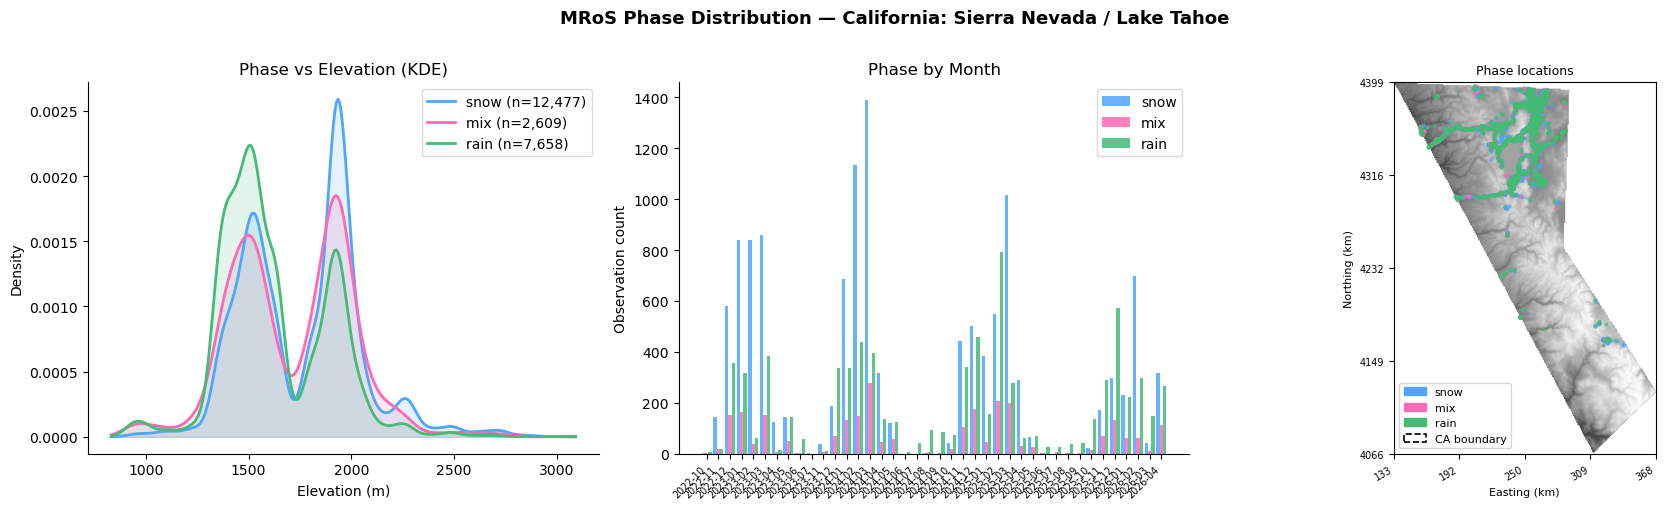


Phase totals:
phase
snow             12488
rain              7663
mix               2612
graupel             43
fog                 36
sleet                3
freezing fog         2
hail                 2
freezing rain        1
Name: count, dtype: int64


In [38]:
# -------------------- VISUALIZE: MRoS phase distribution ----------------
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from rasterio.plot import show as rio_show
import geopandas as gpd
import numpy as np

PHASE_COLORS = {"snow": "#4da6ff", "mix": "#ff69b4", "rain": "#44bb77"}
PHASE_ORDER  = ["snow", "mix", "rain"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"MRoS Phase Distribution — {rcfg['label']}", fontsize=13, fontweight="bold", y=1.01)

# ── 1. Elevation KDE by phase ──────────────────────────────────────────────
ax = axes[0]
from scipy.stats import gaussian_kde


for phase in PHASE_ORDER:
    sub = mros_hr.loc[mros_hr["phase"] == phase, "elev"].dropna()
    if len(sub) < 2:
        continue
    kde = gaussian_kde(sub, bw_method="scott")
    elev_range = np.linspace(mros_hr["elev"].dropna().min(),
                             mros_hr["elev"].dropna().max(), 300)
    density = kde(elev_range)
    ax.plot(elev_range, density, color=PHASE_COLORS[phase],
            linewidth=2, label=f"{phase} (n={len(sub):,})")
    ax.fill_between(elev_range, density, alpha=0.15, color=PHASE_COLORS[phase])

ax.set_xlabel("Elevation (m)")
ax.set_ylabel("Density")
ax.set_title("Phase vs Elevation (KDE)")
ax.legend(framealpha=0.7)
ax.spines[["top","right"]].set_visible(False)

# ── 2. Monthly phase counts ───────────────────────────────────────────────
ax = axes[1]
tmp = mros_hr.copy()
tmp["month"] = pd.to_datetime(tmp["hour_utc"]).dt.to_period("M").astype(str)
monthly = (tmp.groupby(["month","phase"])
              .size()
              .unstack(fill_value=0)
              .reindex(columns=PHASE_ORDER, fill_value=0))
months = monthly.index.tolist()
x = np.arange(len(months))
width = 0.28
for i, phase in enumerate(PHASE_ORDER):
    ax.bar(x + i*width, monthly[phase], width=width,
           color=PHASE_COLORS[phase], label=phase, alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(months, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Observation count")
ax.set_title("Phase by Month")
ax.legend(framealpha=0.7)
ax.spines[["top","right"]].set_visible(False)

# ── 3. Spatial: DEM + phase-colored MRoS points ──────────────────────────
ax = axes[2]
with rio.open(CONFIG["dem_path"]) as src:
    dem_crs = src.crs
    dem_crs_str = src.crs.to_string()
    bounds = src.bounds
    rio_show(src, ax=ax, cmap="Greys_r", alpha=0.75, title="Phase locations")

mros_gdf = gpd.GeoDataFrame(
    mros_hr,
    geometry=gpd.points_from_xy(mros_hr["lon"], mros_hr["lat"]),
    crs="EPSG:4326",
).to_crs(dem_crs_str)

for phase in PHASE_ORDER:
    sub = mros_gdf[mros_gdf["phase"] == phase]
    sub.plot(ax=ax, markersize=4, color=PHASE_COLORS[phase],
             alpha=0.55, label=phase)
# for i, phase in enumerate(PHASE_ORDER):
#     sub = mros_gdf[mros_gdf["phase"] == phase]
#     ax.hexbin(sub.geometry.x, sub.geometry.y,
#               gridsize=40, cmap={"snow":"Blues","mix":"RdPu","rain":"Greens"}[phase],
#               alpha=0.6, mincnt=1)


# --- Northing / Easting tick labels ---
ax.set_axis_on()
ax.spines[["top", "right", "left", "bottom"]].set_visible(True)

# X ticks → Easting
xticks = np.linspace(bounds.left, bounds.right, 5)
ax.set_xticks(xticks)
ax.set_xticklabels([f"{x/1000:.0f}" for x in xticks], fontsize=7, rotation=30, ha="right")
ax.set_xlabel("Easting (km)", fontsize=8)

# Y ticks → Northing
yticks = np.linspace(bounds.bottom, bounds.top, 5)
ax.set_yticks(yticks)
ax.set_yticklabels([f"{y/1000:.0f}" for y in yticks], fontsize=7)
ax.set_ylabel("Northing (km)", fontsize=8)

ax.set_title("Phase locations", fontsize=9)

patches = [mpatches.Patch(color=PHASE_COLORS[p], label=p) for p in PHASE_ORDER]
ca_line = mpatches.Patch(facecolor="none", edgecolor="black",
                          linestyle="--", linewidth=1.2, label="CA boundary")
ax.legend(handles=patches + [ca_line], loc="lower left", framealpha=0.8, fontsize=8)

plt.tight_layout()
plt.savefig(out_dir / f"mros_phase_diagnostics_{REGION}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nPhase totals:\n{mros_hr['phase'].value_counts()}")


# AOI clipping

In [39]:
# -------------------- LOAD: DEM & AOI functions ------------------------
import rasterio
from shapely.geometry import Polygon
from pyproj import Transformer as ProjTransformer

# Load already projected and clipped 1km DEM (from preprocessing_DEM.ipynb)
with rasterio.open(CONFIG["dem_path"]) as src:
    dem           = src.read(1)
    dem_profile   = src.profile
    dem_crs       = src.crs
    dem_transform = src.transform
    dem_bounds    = src.bounds

# AOI polygon: use actual polygon vertices (WGS84) — same as preprocessing_DEM.ipynb
# Reproject to WGS84 for spatial filtering of station/IMERG/MRoS points
_t = ProjTransformer.from_crs(CRS_DEM, CRS_WGS84, always_xy=True)
# Build polygon directly from config vertices (already in WGS84)
aoi_poly = Polygon(rcfg["aoi_lonlat"])

def grid_centers(profile):
    T = profile["transform"]
    xs = T.c + (np.arange(profile["width"]) + 0.5) * T.a
    ys = T.f + (np.arange(profile["height"]) + 0.5) * T.e
    X, Y = np.meshgrid(xs, ys)
    return np.column_stack([X.ravel(), Y.ravel()])

grid_xy   = grid_centers(dem_profile)
grid_elev = dem.ravel()
proj_crs  = dem_crs

print(f"DEM shape  : {dem.shape}")
print(f"DEM CRS    : {dem_crs}")
print(f"DEM bounds : {dem_bounds}")
print(f"AOI polygon: {len(rcfg['aoi_lonlat'])} vertices")


DEM shape  : (333, 235)
DEM CRS    : EPSG:26911
DEM bounds : BoundingBox(left=132830.58548976987, bottom=4065984.824855651, right=367830.5854897699, top=4398984.824855651)
AOI polygon: 5 vertices


In [40]:
# Filter points to unclipped AOI

def filter_points_to_aoi(df, aoi_poly):
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs=CRS_WGS84
    )
    mask = gdf.within(aoi_poly)
    return df.loc[mask.values]

st_hr   = filter_points_to_aoi(st_hr, aoi_poly)
imerg_hr= filter_points_to_aoi(imerg_hr, aoi_poly)
mros_hr = filter_points_to_aoi(mros_hr, aoi_poly)

print("Counts inside AOI:",
      len(st_hr), len(imerg_hr), len(mros_hr))

Counts inside AOI: 1225738 6910080 22846


In [41]:
# Save hourly processed data to parquets!

import pyarrow as pa
import pyarrow.parquet as pq

# Convert DataFrame → Arrow Table → Parquet
pq.write_table(pa.Table.from_pandas(st_hr), out_dir / "hourly_data/stations_hourly.parquet")
pq.write_table(pa.Table.from_pandas(imerg_hr), out_dir / "hourly_data/imerg_hourly.parquet")
pq.write_table(pa.Table.from_pandas(mros_hr), out_dir / "hourly_data/mros_hourly.parquet")

In [5]:
# Load hourly-level stations, IMERG, and MRoS if already performed:

st_hr   = pd.read_parquet(out_dir / "hourly_data/stations_hourly.parquet")
imerg_hr = pd.read_parquet(out_dir / "hourly_data/imerg_hourly.parquet")
mros_hr     = pd.read_parquet(out_dir / "hourly_data/mros_hourly.parquet")

# Additional dataset investigations

In [42]:
# How many MRoS reports per hour?
mros_counts = mros_hr.groupby("hour_utc").size().rename("n_mros")
print(mros_counts.describe())
print("hours with >=3:", (mros_counts>=3).sum(), " | >=2:", (mros_counts>=2).sum(), " | >=1:", (mros_counts>=1).sum())

h = pd.Timestamp("2024-10-17 21:00:00+00:00")
print(mros_hr.loc[mros_hr["hour_utc"]==h, ["lat","lon","phase","mros_plp_proxy"]].head(10))

count    4033.000000
mean        5.664766
std         6.756992
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max        74.000000
Name: n_mros, dtype: float64
hours with >=3: 2274  | >=2: 2874  | >=1: 4033
             lat         lon phase  mros_plp_proxy
15740  39.559113 -119.687039   mix            50.0
15741  39.513343 -119.781537  rain           100.0
15742  39.560036 -119.744263  rain           100.0
15743  39.602421 -119.869310  rain           100.0
15744  39.088338 -119.775831  rain           100.0


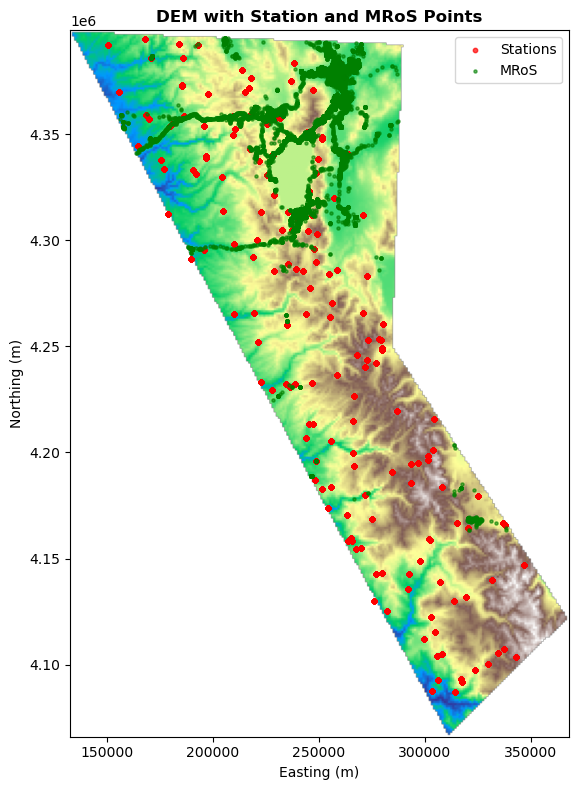

In [ ]:
# ------------------ VISUALIZE: DEM + all data points --------------------
import matplotlib.pyplot as plt
from rasterio.plot import show

# Read DEM again for plotting
with rio.open(CONFIG["dem_path"]) as src:
    fig, ax = plt.subplots(figsize=(10, 8))
    show(src, ax=ax, cmap="terrain", title="DEM with Station and MRoS Points")

# Convert to GeoDataFrames for easy overlay
st_gdf = gpd.GeoDataFrame(st_hr, geometry=gpd.points_from_xy(st_hr["lon"], st_hr["lat"]), crs="EPSG:4326")
mros_gdf = gpd.GeoDataFrame(mros_hr, geometry=gpd.points_from_xy(mros_hr["lon"], mros_hr["lat"]), crs="EPSG:4326")

# Reproject to DEM CRS
st_gdf = st_gdf.to_crs(src.crs)
mros_gdf = mros_gdf.to_crs(src.crs)

# Plot each dataset
st_gdf.plot(ax=ax, markersize=10, color="red", label="Stations", alpha=0.7)
mros_gdf.plot(ax=ax, markersize=5, color="black", label="MRoS", alpha=0.6)

plt.legend()
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.tight_layout()
plt.show()


In [9]:
# import contextily as cx

#=== Load DEM and extract bounds ===#
with rio.open(CONFIG["dem_path"]) as src:
    bounds = src.bounds
    crs = src.crs

# Calculate width, height, and area
width_m  = bounds.right  - bounds.left
height_m = bounds.top    - bounds.bottom

area_m2  = width_m * height_m
area_km2 = area_m2 / 1_000_000

print(f"Width:  {width_m:,.0f} m")
print(f"Height: {height_m:,.0f} m")
print(f"Area:   {area_km2:,.2f} square km")

# #=== Create DEM bounding box and buffered extent ===#
# dem_poly = box(*bounds)
# # buffer_dist = 300_000  # adjust to widen the view (~300 km)
# buffer_dist = 5_000  # adjust to widen the view (~300 km)
# region_poly = dem_poly.buffer(buffer_dist)

# # Convert DEM polygon to Web Mercator
# dem_gdf = gpd.GeoDataFrame({"geometry": [dem_poly]}, crs=CRS_DEM).to_crs(CRS_WEB)
# region_gdf = gpd.GeoDataFrame({"geometry": [region_poly]}, crs=CRS_DEM).to_crs(CRS_WEB)

# #=== Plot ===#
# fig, ax = plt.subplots(figsize=(8, 8))

# # Plot DEM footprint (red)
# dem_gdf.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=2)

# # Set zoom extent based on buffered region, but don't draw it
# xmin, ymin, xmax, ymax = region_gdf.total_bounds
# ax.set_xlim(xmin, xmax)
# ax.set_ylim(ymin, ymax)

# # Add basemap
# cx.add_basemap(ax, source=cx.providers.Esri.WorldImagery, zoom=10)

# #=== Lat/Long tick labels ===#
# to_latlon = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)
# xticks = ax.get_xticks()
# yticks = ax.get_yticks()

# xlon, _ = to_latlon.transform(xticks, [0]*len(xticks))
# _, ylat = to_latlon.transform([0]*len(yticks), yticks)

# ax.set_xticklabels([f"{lon:.2f}°" for lon in xlon])
# ax.set_yticklabels([f"{lat:.2f}°" for lat in ylat])

# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")

# ax.set_title(f"{rcfg['label']} — DEM Footprint")
# ax.set_axis_on()
# plt.tight_layout()
# plt.show()


Width:  235,000 m
Height: 333,000 m
Area:   78,255.00 square km
